In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jacksondivakarr/sample34")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/jacksondivakarr/sample34/versions/1


In [3]:
path_file = path + "/processes2.csv"

In [4]:
df = pd.read_csv(path_file)
df.head()

,Unnamed: 0,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power (in bph),Mileage Unit,Mileage,Engine (CC)
0,0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,5,74.00,kmpl,23.40,1248
1,2,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,5,90.00,kmpl,23.00,1396
2,4,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,5,81.86,kmpl,20.14,1197
3,7,Toyota,2011,350000,90000,Diesel,Individual,Manual,First Owner,5,67.10,kmpl,23.59,1364
4,8,Ford,2013,200000,169000,Diesel,Individual,Manual,First Owner,5,68.10,kmpl,20.00,1399


In [5]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['unnamed:_0', 'name', 'year', 'selling_price', 'km_driven', 'fuel',
       'seller_type', 'transmission', 'owner', 'seats', 'max_power_(in_bph)',
       'mileage_unit', 'mileage', 'engine_(cc)'],
      dtype='str')

In [6]:
df.drop(columns=['unnamed:_0'], inplace=True)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power_(in_bph),mileage_unit,mileage,engine_(cc)
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,5,74.00,kmpl,23.40,1248
1,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,5,90.00,kmpl,23.00,1396
2,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,5,81.86,kmpl,20.14,1197
3,Toyota,2011,350000,90000,Diesel,Individual,Manual,First Owner,5,67.10,kmpl,23.59,1364
4,Ford,2013,200000,169000,Diesel,Individual,Manual,First Owner,5,68.10,kmpl,20.00,1399


In [7]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power_(in_bph),mileage_unit,mileage,engine_(cc)
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,5,74.00,kmpl,23.40,1248
1,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,5,90.00,kmpl,23.00,1396
2,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,5,81.86,kmpl,20.14,1197
3,Toyota,2011,350000,90000,Diesel,Individual,Manual,First Owner,5,67.10,kmpl,23.59,1364
4,Ford,2013,200000,169000,Diesel,Individual,Manual,First Owner,5,68.10,kmpl,20.00,1399


In [8]:
for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].str.lower()

In [9]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power_(in_bph),mileage_unit,mileage,engine_(cc)
0,maruti,2014,450000,145500,diesel,individual,manual,first owner,5,74.00,kmpl,23.40,1248
1,hyundai,2010,225000,127000,diesel,individual,manual,first owner,5,90.00,kmpl,23.00,1396
2,hyundai,2017,440000,45000,petrol,individual,manual,first owner,5,81.86,kmpl,20.14,1197
3,toyota,2011,350000,90000,diesel,individual,manual,first owner,5,67.10,kmpl,23.59,1364
4,ford,2013,200000,169000,diesel,individual,manual,first owner,5,68.10,kmpl,20.00,1399


<Axes: xlabel='selling_price', ylabel='Count'>

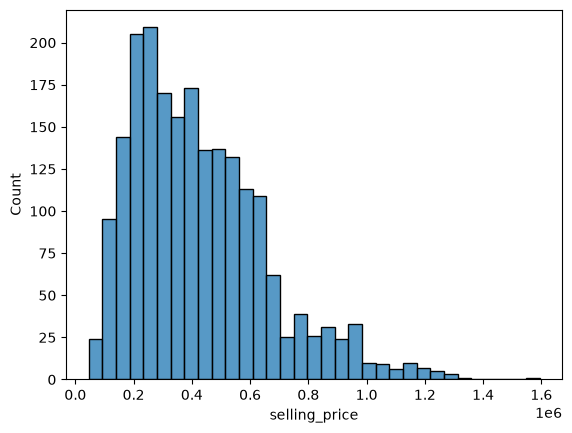

In [10]:
sns.histplot(df.selling_price)

In [11]:
df.selling_price.describe()

count    2.095000e+03
mean     4.272799e+05
std      2.326698e+05
min      4.595700e+04
25%      2.500000e+05
50%      3.900000e+05
75%      5.555000e+05
max      1.594000e+06
Name: selling_price, dtype: float64

<Axes: xlabel='selling_price', ylabel='Count'>

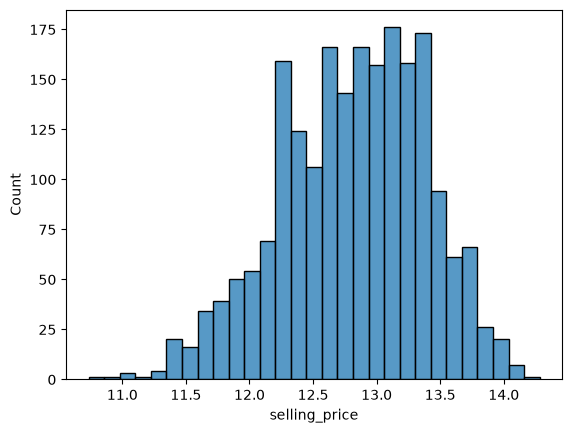

In [12]:
sns.histplot(np.log1p(df.selling_price))

In [13]:
len(df)

2095

In [16]:
idx = np.arange(len(df))

In [17]:
np.random.seed(42)
np.random.shuffle(idx)

In [31]:
n_train = int(len(df)*0.6)
n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train, n_val, n_test

(1257, 419, 419)

In [32]:
df_train = df.iloc[idx[:n_train]]
print(df_train.index)

Index([ 210, 1169, 1146,  879,   29,  485, 1102, 1652,  324,  579,
       ...
        989,  388,  235, 1622,  267, 1543,  117, 1724,  673,  249],
      dtype='int64', length=1257)


In [35]:
df_val = df.iloc[idx[n_train: n_train+n_val]]
print(df_val.index)

Index([1565, 2091,   94,   33, 1957, 1793,  448,  716, 1362, 1837,
       ...
        154, 1662,  961,  853, 1311,  625,  685, 1940,  569,  565],
      dtype='int64', length=419)


In [36]:
df_test = df.iloc[idx[n_train+n_val:]]
print(df_test.index)

Index([  17,  127, 1346, 1279, 2079,  927,  980,  252,  190, 1139,
       ...
        130, 1482,  330, 1238,  466, 1638, 1095, 1130, 1294,  860],
      dtype='int64', length=419)


In [39]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [38]:
y_train = np.log1p(df_train['selling_price'])
y_test = np.log1p(df_test['selling_price'])
y_val = np.log1p(df_val['selling_price'])

In [41]:
del(df_train['selling_price'])
del(df_val['selling_price'])
del(df_test['selling_price'])